# Morse potential

According to Wikipedia:

*The Morse potential, named after physicist Philip M. Morse, is a convenient interatomic interaction model for the potential energy of a diatomic molecule. It is a better approximation for the vibrational structure of the molecule than the quantum harmonic oscillator because it explicitly includes the effects of bond breaking, such as the existence of unbound states. It also accounts for the anharmonicity of real bonds and the non-zero transition probability for overtone and combination bands.*

The mathematical form of the potential is

$$
V(r) = D_e(1-e^{-a(r-r_e)})^2
$$

where $D_e$ is the depth of the potential energy well, $a$ relates to the width of the potential well, and $r_e$ is the equilibrium distance between the two atoms. 

Using

- $D_e = 2$
- $a = 1.5$
- $r_e = 0.5$

we get:

At a potential energy of 1, the distance between the atoms oscillates between 0.14 and 1.32.


Text(0, 0.5, 'Potential energy (a.u.)')

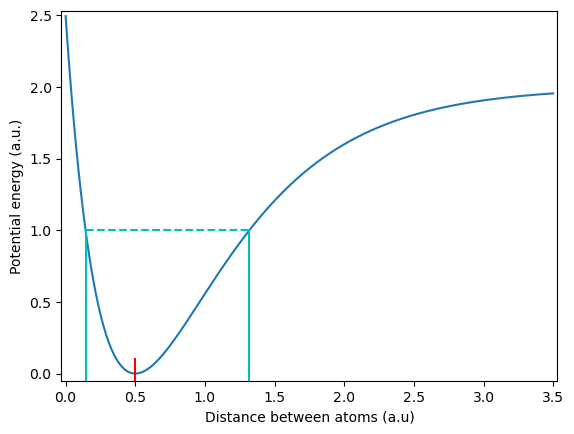

In [31]:
import numpy as np
import matplotlib.pyplot as plt

De = 2
a = 1.5
re = 0.5

def morse_pot(r):
    return De*np.power((1-np.exp(-a*(r-re))),2)

r = np.linspace(0, 3.5, num = 1000)
pot_energy = morse_pot(r)

indices = np.where((pot_energy >= 0.995) & (pot_energy <= 1.0))[0]

r_1 = r[indices[0]]
r_2 = r[indices[1]]

print(f"At a potential energy of 1, the distance between the atoms oscillates between {r_1:.2f} and {r_2:.2f}.")

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(r, pot_energy)
ax1.plot([0.5, 0.5], [-0.05, 0.1], "r")
ax1.plot([r_1, r_1], [-0.05, 1.0], "c")
ax1.plot([r_2, r_2], [-0.05, 1.0], "c")
ax1.plot([r_1, r_2], [1.0, 1.0], "c", linestyle='dashed')
ax1.set_xlim(-0.03, 3.53)
ax1.set_ylim(-0.05, 2.53)
ax1.set_xlabel("Distance between atoms (a.u)")
ax1.set_ylabel("Potential energy (a.u.)")

Observing this potential, we see:

- The minimum energy occurs at $r_e = 0.5$. This is the equilibrium distance between the atoms. Unless excited, in some way, this is spacing between atoms.
- If the molecule is excited to a potential energy of 1, the distance between the atoms oscillates between $r=0.14$ and $r=1.32$. The exact equation for the distance in time will be complicated because of the shape of the potential well.
- If the molecule is excited to a potential energy greater than 2, the distance between the atoms can become infinite. We say that the molecule has dissociated.
- No matter how high the potential energy is, the atoms can never be in contact.

## Taylor series

If we want to get a sense for how the molecules vibrate (atoms oscillating in time), we can use a Taylor series. We will expand it around $r_e$.

$$
V(r) \approx V(r_e) + V'(r_e)(r-r_e) + \frac{V''(r_e)}{2}(r-r_e)^2 + \frac{V'''(r_e)}{6}*(r-r_e)^3 + \ldots
$$

We derive the terms one at a time:

- $V(r_e) = D_e(1-e^{-a(r_e-r_e)})^2 = D_e(1-e^{-a(0)})^2 = D_e(1-1)^2 = 0$
- $V'(r) = 2D_e((1-e^{-a(r_e-r_e)})(a e^{-a(r-r_e}) \rightarrow V'(r_e) = 0$
- $v''(r) = 2D_e(a e^{-a(r-r_e)})^2 - 2a^2D_e((1-e^{-a(r_e-r_e)})e^{-a(r-r_e)} \rightarrow V''(r_e) = 2D_e a^2$

The second order term is the first non-zero one. We can rewrite the potential as:

$$
V(r) \approx D_ea^2(r-r_e)^2
$$

We plot this below.

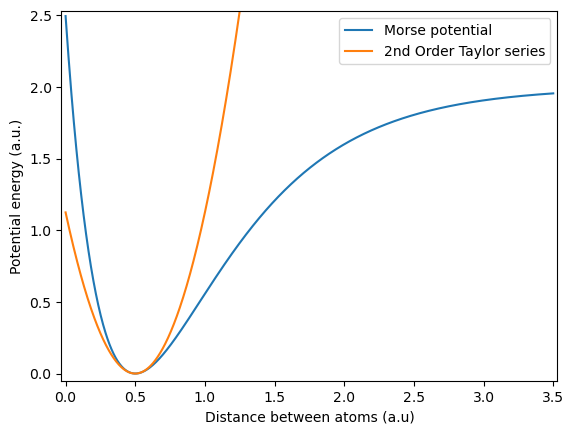

In [34]:
def taylor_pot(r):
    return De*a**2*(r-re)**2

fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(r, pot_energy, label='Morse potential')
ax2.plot(r, taylor_pot(r), label='2nd Order Taylor series')
ax2.set_xlim(-0.03, 3.53)
ax2.set_ylim(-0.05, 2.53)
ax2.set_xlabel("Distance between atoms (a.u)")
ax2.set_ylabel("Potential energy (a.u.)")
ax2.legend(loc='upper right')

- Adding more orders to the approximation would result in a better match.
- Near $r_e$, the harmonic potential (quadratic) is a good approximation.
- Hence, at low energy near $r_e$, the diatomic molecule vibrates in simple harmonic motion.